In [23]:
# Cell 1 — imports & settings
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score
import matplotlib.pyplot as plt

np.random.seed(0)


In [54]:
# Cell 2 — load data (adjust path if needed)
df = pd.read_csv('Groceries data (1).csv')   # uploaded file path
df.head()




,Member_number,Date,itemDescription,year,month,day,day_of_week
0,1808,2015-07-21,tropical fruit,2015,7,21,1
1,2552,2015-05-01,whole milk,2015,5,1,4
2,2300,2015-09-19,pip fruit,2015,9,19,5
3,1187,2015-12-12,other vegetables,2015,12,12,5
4,3037,2015-01-02,whole milk,2015,1,2,4


In [55]:
# Expect columns: Member_number, itemDescription (others ignored)
df = df[['Member_number', 'itemDescription']].dropna()
df['itemDescription'] = df['itemDescription'].str.strip().str.lower()

In [56]:
# Cell 3 — group items per member and filter to top N items
N_ITEMS = 20   # change to top N items to keep
grouped = df.groupby('Member_number')['itemDescription'].apply(list)
item_counts = Counter(x for items in grouped for x in set(items))  # presence-based
top_items = [it for it, _ in item_counts.most_common(N_ITEMS)]
print("Top items:", top_items)


Top items: ['whole milk', 'other vegetables', 'rolls/buns', 'soda', 'yogurt', 'tropical fruit', 'root vegetables', 'bottled water', 'sausage', 'citrus fruit', 'pastry', 'pip fruit', 'shopping bags', 'canned beer', 'bottled beer', 'whipped/sour cream', 'newspapers', 'frankfurter', 'brown bread', 'domestic eggs']


In [57]:
# Cell 4 — build binary basket matrix (rows = members, cols = top_items)
members = grouped.index.to_list()
X = np.zeros((len(members), len(top_items)), dtype=np.int8)
for i, items in enumerate(grouped):
    s = set(items)
    for j, it in enumerate(top_items):
        if it in s: X[i, j] = 1
basket_df = pd.DataFrame(X, index=members, columns=top_items)
basket_df.head()


,whole milk,other vegetables,rolls/buns,soda,yogurt,tropical fruit,root vegetables,bottled water,sausage,citrus fruit,pastry,pip fruit,shopping bags,canned beer,bottled beer,whipped/sour cream,newspapers,frankfurter,brown bread,domestic eggs
1000,1,0,0,1,1,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0
1001,1,0,1,1,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0
1002,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1003,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0
1004,1,1,1,0,0,1,1,0,0,0,1,1,1,1,0,0,0,0,0,0


In [58]:
# Cell 5 — train/test split (split members)
train_idx, test_idx = train_test_split(np.arange(len(members)), test_size=0.2, random_state=0)
X_train, X_test = X[train_idx], X[test_idx]


In [59]:
# Cell 6 — simple Bernoulli Mixture EM implementation
def fit_bernoulli_mixture(X, K=5, max_iter=100, tol=1e-4, verbose=False):
    N, D = X.shape
    # initialize
    pi = np.full(K, 1.0/K)
    theta = np.clip(np.random.rand(K, D), 0.01, 0.99)
    log_likes = []
    eps = 1e-9

    for it in range(max_iter):
        # E-step: responsibilities r[n,k]
        # compute log p(x_n | k) in log-space for numeric stability
        log_prob = (X @ np.log(theta + eps).T) + ((1 - X) @ np.log(1 - theta + eps).T)  # shape N x K
        log_weighted = log_prob + np.log(pi + eps)
        # normalize in log-space
        amax = log_weighted.max(axis=1, keepdims=True)
        resp = np.exp(log_weighted - amax)
        resp = resp / resp.sum(axis=1, keepdims=True)  # N x K

        # log-likelihood
        ll = np.sum(amax.flatten() + np.log(resp.sum(axis=1) + eps))  # stable total ll
        log_likes.append(ll)
        if verbose and it % 10 == 0:
            print(f"iter {it} ll={ll:.4f}")

        # M-step
        Nk = resp.sum(axis=0)  # size K
        pi = Nk / N
        theta = (resp.T @ X) / Nk[:, None]
        # clip
        theta = np.clip(theta, 1e-6, 1 - 1e-6)

        # convergence
        if it > 0 and abs(log_likes[-1] - log_likes[-2]) < tol:
            break

    return {'pi': pi, 'theta': theta, 'resp': resp, 'log_likes': log_likes}

# fit
K = 5  # number of clusters — tuneable
model = fit_bernoulli_mixture(X_train, K=K, max_iter=200, verbose=True)


iter 0 ll=-51845.8773
iter 10 ll=-32611.8138
iter 20 ll=-32629.4146
iter 30 ll=-32647.8795
iter 40 ll=-32663.8337
iter 50 ll=-32677.9981
iter 60 ll=-32690.2412
iter 70 ll=-32699.6771
iter 80 ll=-32706.3584
iter 90 ll=-32709.3242
iter 100 ll=-32704.1402
iter 110 ll=-32700.8116
iter 120 ll=-32698.9186
iter 130 ll=-32696.6893
iter 140 ll=-32694.6126
iter 150 ll=-32692.4759
iter 160 ll=-32690.0113
iter 170 ll=-32686.7539
iter 180 ll=-32683.3595
iter 190 ll=-32679.7628


In [60]:
# Cell 7 — helper: given observed items (mask or list), compute P(item_j=1 | observed)
def predict_cooccurrence(model, observed_mask):
    # observed_mask: binary vector length D with 1 for observed items, 0 elsewhere
    pi, theta = model['pi'], model['theta']  # theta: K x D
    eps = 1e-9
    # compute P(k | observed) using only observed features (use log for stability)
    obs_idx = np.where(observed_mask == 1)[0]
    if obs_idx.size == 0:
        post = pi  # no observation -> prior
    else:
        # log p(obs | k)
        logp = np.sum(np.log(theta[:, obs_idx] + eps) , axis=1)  # assuming observed items are 1
        logp += np.log(pi + eps)
        logp -= logp.max()
        post = np.exp(logp)
        post = post / post.sum()
    # predictive probability for each item
    p_items = post @ theta  # size D
    return p_items, post

# Example: given target item purchased, recommend top 10 co-occurring items
target = 'whole milk'
if target in top_items:
    obs = np.zeros(len(top_items), dtype=int)
    obs[top_items.index(target)] = 1
    p_items, post = predict_cooccurrence(model, obs)
    # exclude the observed item
    idx_sorted = np.argsort(p_items)[::-1]
    recommendations = [(top_items[i], float(p_items[i])) for i in idx_sorted if top_items[i] != target][:10]
    print("Top co-occurring items given", target)
    for it, p in recommendations:
        print(f"{it}: {p:.3f}")
else:
    print(target,"not in top_items; choose another item from top_items.")


Top co-occurring items given whole milk
other vegetables: 0.423
rolls/buns: 0.383
soda: 0.343
yogurt: 0.331
tropical fruit: 0.256
bottled water: 0.252
root vegetables: 0.242
sausage: 0.235
citrus fruit: 0.206
pastry: 0.200


In [66]:
# Cell 8 — Evaluation: Precision@K, Recall@K, F1@K
# We'll do a simple leave-one-out style: for each test basket with >=2 items, hide one item as the target.
import random
def evaluate_topk(model, X_test, top_items, K_list=[1,3,5,10], trials_per_basket=1):
    D = X_test.shape[1]
    results = {k: {'tp':0, 'total_pred':0, 'total_true':0} for k in K_list}
    for row in X_test:
        ones = np.where(row==1)[0]
        if len(ones) < 2:
            continue
        for _ in range(trials_per_basket):
            target = np.random.choice(ones)
            observed = row.copy()
            observed[target] = 0  # hide target
            p_items, _ = predict_cooccurrence(model, observed)
            # rank items excluding observed ones
            ranked = np.argsort(p_items)[::-1]
            for k in K_list:
                topk = ranked[:k]
                hit = int(target in topk)
                results[k]['tp'] += hit
                results[k]['total_pred'] += k
                results[k]['total_true'] += 1
    # compute precision@k, recall@k, f1@k
    metrics = {}
    for k in K_list:
        tp = results[k]['tp']
        prec = tp / results[k]['total_pred'] if results[k]['total_pred']>0 else 0
        rec = tp / results[k]['total_true'] if results[k]['total_true']>0 else 0
        f1 = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0
        metrics[k] = { 'precision':prec,   'recall':rec,   'f1':f1}
    return metrics

metrics = evaluate_topk(model, X_test, top_items, K_list=[1,3,5,10])

print("Evaluation metrics (hold-one-out):")

# Convert dictionary → DataFrame for tabular display
metrics_df = pd.DataFrame(metrics).T  # transpose so K values are rows
metrics_df.index.name = "K"
metrics_df = metrics_df.reset_index()

# Pretty print
print(metrics_df.to_string(index=False, float_format="%.4f"))


Evaluation metrics (hold-one-out):
 K  precision  recall     f1
 1     0.1066  0.1066 0.1066
 3     0.0893  0.2680 0.1340
 5     0.0795  0.3977 0.1326
10     0.0618  0.6182 0.1124


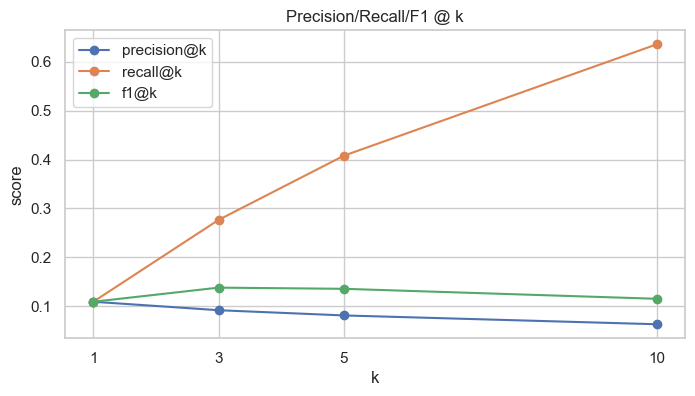

In [64]:
# Cell 9 — Plot precision@k / recall@k / f1@k (bar plot)
Ks = [1,3,5,10]
prec = [metrics[k]['precision'] for k in Ks]
rec = [metrics[k]['recall'] for k in Ks]
f1 = [metrics[k]['f1'] for k in Ks]

plt.figure(figsize=(8,4))
plt.plot(Ks, prec, marker='o', label='precision@k')
plt.plot(Ks, rec, marker='o', label='recall@k')
plt.plot(Ks, f1, marker='o', label='f1@k')
plt.xlabel('k')
plt.xticks(Ks)
plt.ylabel('score')
plt.legend()
plt.title('Precision/Recall/F1 @ k')
plt.grid(True)
plt.show()


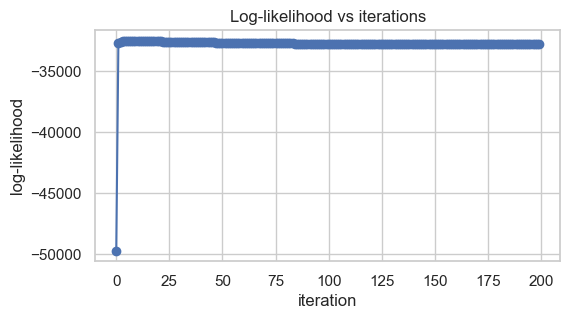

In [47]:
# Cell 10 — Plot log-likelihood vs iterations
ll = model['log_likes']
plt.figure(figsize=(6,3))
plt.plot(np.arange(len(ll)), ll, marker='o')
plt.xlabel('iteration')
plt.ylabel('log-likelihood')
plt.title('Log-likelihood vs iterations')
plt.grid(True)
plt.show()


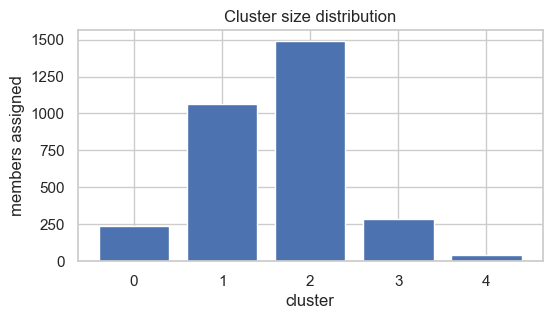

In [67]:
# Cell 11 — Cluster size distribution (hard assign by max responsibility)
hard = model['resp'].argmax(axis=1)
counts = np.bincount(hard, minlength=K)
plt.figure(figsize=(6,3))
plt.bar(range(K), counts)
plt.xlabel('cluster')
plt.ylabel('members assigned')
plt.title('Cluster size distribution')
plt.show()


In [50]:
# Cell 13 — quick utilities: show top items per cluster
for k in range(K):
    topk = np.argsort(theta[k])[::-1][:8]
    print(f"Cluster {k}: ", ", ".join(f"{top_items[i]}({theta[k,i]:.2f})" for i in topk))


Cluster 0:  soda(0.43), rolls/buns(0.43), other vegetables(0.42), whole milk(0.41), root vegetables(0.33), yogurt(0.29), pastry(0.28), citrus fruit(0.27)
Cluster 1:  bottled water(0.65), whole milk(0.54), other vegetables(0.49), brown bread(0.31), citrus fruit(0.30), frankfurter(0.30), sausage(0.28), yogurt(0.22)
Cluster 2:  whole milk(0.30), other vegetables(0.27), rolls/buns(0.22), soda(0.22), yogurt(0.16), tropical fruit(0.14), root vegetables(0.14), citrus fruit(0.12)
Cluster 3:  whole milk(0.86), other vegetables(0.68), rolls/buns(0.66), soda(0.58), yogurt(0.54), shopping bags(0.48), bottled water(0.47), brown bread(0.42)
Cluster 4:  whole milk(0.67), yogurt(0.44), other vegetables(0.43), rolls/buns(0.42), tropical fruit(0.37), sausage(0.32), soda(0.29), whipped/sour cream(0.27)
